In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader,ConcatDataset
from LSTM_databuilder import AssistSequenceDataset
from LSTM_model_train import AssistLSTM
import os
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path(r"C:\Users\loy49\Desktop\REPO\LSTM_HRC")

if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))
    
from data_proc_2d.app.build_norm_dataset import NormDatasetBuilder


In [2]:
#device 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


### hyper param short epoch test

In [ ]:
# #training config
# epochs = 60
# batch_size = 32
# lr = 3e-4

# #sliding window config
# window_size = 160
# stride = 30
# predict_offset = 0
# num_workers = 4

# mode = "seq2one"  # "seq2one" or "seq2seq"

# hidden_layer = 64

# train_shuffle = False


### hyper param optimization

In [ ]:
#training config
epochs = 60
batch_size = 32
lr = 3e-4

#sliding window config
window_size = 160
stride = 30
predict_offset = 0
num_workers = 4

mode = "seq2one"  # "seq2one" or "seq2seq"

hidden_layer = 64

train_shuffle = False

## load training data

In [4]:
npz_dir = r"G:\.shortcut-targets-by-id\1nZZWQUKOdxeC-oo-NKucbuUj38ir4mZC\ITECH_Thesis\Videos\dataset_3d\train\norm"
npz_paths = [os.path.join(npz_dir, f) for f in os.listdir(npz_dir) if f.endswith(".npz")]
datasets = []
print(len(npz_paths))

73


## load norm.npz

In [5]:

norm_stats = np.load(r"C:\Users\loy49\Desktop\REPO\LSTM_HRC\data_proc_3d\dataset\norm_2026-08-16.npz", allow_pickle=True)  

## load & norm val data

In [6]:
val_dir = r"G:\.shortcut-targets-by-id\1nZZWQUKOdxeC-oo-NKucbuUj38ir4mZC\ITECH_Thesis\Videos\dataset_3d\val\raw"
val_paths = [os.path.join(val_dir, f) for f in os.listdir(val_dir) if f.endswith(".pt")]

npz_val_dir = r"G:\.shortcut-targets-by-id\1nZZWQUKOdxeC-oo-NKucbuUj38ir4mZC\ITECH_Thesis\Videos\dataset_3d\val\norm"

In [7]:
if len(os.listdir(npz_val_dir)) <=1:

    builder = NormDatasetBuilder(norm_stats)

    #norm val dataset
    for val_path in val_paths:
        out_path = os.path.join(npz_val_dir, os.path.basename(val_path).replace(".pt", "_norm.npz"))
        builder.build_dataset(val_path,out_path)
    print("Validation dataset normalization complete.")

In [8]:

npz_val_paths = [os.path.join(npz_val_dir, f) for f in os.listdir(npz_val_dir) if f.endswith(".npz")]
print(len(npz_val_paths))

9


## load & norm test data

In [9]:
test_dir = r"G:\.shortcut-targets-by-id\1nZZWQUKOdxeC-oo-NKucbuUj38ir4mZC\ITECH_Thesis\Videos\dataset_3d\test\raw"
test_paths = [os.path.join(test_dir, f) for f in os.listdir(test_dir) if f.endswith(".pt")]

npz_test_dir = r"G:\.shortcut-targets-by-id\1nZZWQUKOdxeC-oo-NKucbuUj38ir4mZC\ITECH_Thesis\Videos\dataset_3d\test\norm"

In [10]:
if len(os.listdir(npz_test_dir)) <=1:
    builder = NormDatasetBuilder(norm_stats)

    #norm test dataset
    for test_path in test_paths:
        out_path = os.path.join(npz_test_dir, os.path.basename(test_path).replace(".pt", "_norm.npz"))
        builder.build_dataset(test_path,out_path)
    print("Test dataset normalization complete.")

    
npz_test_paths = [os.path.join(npz_test_dir, f) for f in os.listdir(npz_test_dir) if f.endswith(".npz")]
print(len(npz_test_paths))

9


In [11]:
FEATURE_KEYS = [
    'joint_speed', 
    'joint_acceleration', 
    'joint_velocity_x', 
    'joint_velocity_y', 
    'joint_velocity_z', 
    'joint_acceleration_x', 
    'joint_acceleration_y', 
    'joint_acceleration_z', 
    'position_x_relative_to_pelvis', 
    'position_y_relative_to_pelvis', 
    'position_z_relative_to_pelvis', 
    'polar_azimuth', 
    'polar_elevation', 
    'joint_angles', 
    'ratios', 
    'distance_from_center'
]

# Change the selected features here!!

In [12]:
x_keys = [
        "position_z_relative_to_pelvis",
        "ratios"
        ]

## training dataset

In [13]:
for npz_path in npz_paths:
    print(f"Loading dataset from {npz_path}...")
    dataset = AssistSequenceDataset(npz_path=npz_path,
                                    window_size=window_size,
                                    stride=stride,
                                    predict_offset=predict_offset,
                                    mode= mode,
                                    feature_keys=x_keys)
    datasets.append(dataset)

loader = DataLoader(ConcatDataset(datasets), batch_size=batch_size, shuffle=train_shuffle, num_workers=num_workers, pin_memory=(device.type == "cuda"), drop_last=False)
for x, y in loader:
    step = y["step"]
    progress = y["progress"]
    print("Batch X shape:", x.shape)  # should be [batch_size, window_size, feature_dim]
    print("Batch Y-step shape:", step.shape)  # should be [batch_size]
    print("Batch Y-progress shape:", progress.shape)  # should be [batch_size]
    break

Loading dataset from G:\.shortcut-targets-by-id\1nZZWQUKOdxeC-oo-NKucbuUj38ir4mZC\ITECH_Thesis\Videos\dataset_3d\train\norm\features__cam-04_uid-01_take-01_seg-00_norm.npz...
Loading dataset from G:\.shortcut-targets-by-id\1nZZWQUKOdxeC-oo-NKucbuUj38ir4mZC\ITECH_Thesis\Videos\dataset_3d\train\norm\features__cam-04_uid-01_take-01_seg-01_norm.npz...
Loading dataset from G:\.shortcut-targets-by-id\1nZZWQUKOdxeC-oo-NKucbuUj38ir4mZC\ITECH_Thesis\Videos\dataset_3d\train\norm\features__cam-04_uid-01_take-01_seg-03_norm.npz...
Loading dataset from G:\.shortcut-targets-by-id\1nZZWQUKOdxeC-oo-NKucbuUj38ir4mZC\ITECH_Thesis\Videos\dataset_3d\train\norm\features__cam-04_uid-01_take-01_seg-05_norm.npz...
Loading dataset from G:\.shortcut-targets-by-id\1nZZWQUKOdxeC-oo-NKucbuUj38ir4mZC\ITECH_Thesis\Videos\dataset_3d\train\norm\features__cam-04_uid-01_take-01_seg-06_norm.npz...
Loading dataset from G:\.shortcut-targets-by-id\1nZZWQUKOdxeC-oo-NKucbuUj38ir4mZC\ITECH_Thesis\Videos\dataset_3d\train\norm\f

## val dataset

In [14]:
val_datasets = []
for npz_val_path in npz_val_paths:
    print(f"Loading validation dataset from {npz_val_path}...")
    val_dataset = AssistSequenceDataset(npz_path=npz_val_path,
                                        window_size=window_size,
                                        stride=stride,
                                        predict_offset=predict_offset,
                                        mode=mode,
                                        feature_keys=x_keys)
    val_datasets.append(val_dataset)    

val_loader = DataLoader(ConcatDataset(val_datasets), batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=(device.type == "cuda"), drop_last=False)

Loading validation dataset from G:\.shortcut-targets-by-id\1nZZWQUKOdxeC-oo-NKucbuUj38ir4mZC\ITECH_Thesis\Videos\dataset_3d\val\norm\features__cam-04_uid-09_take-02_seg-03_norm.npz...
Loading validation dataset from G:\.shortcut-targets-by-id\1nZZWQUKOdxeC-oo-NKucbuUj38ir4mZC\ITECH_Thesis\Videos\dataset_3d\val\norm\features__cam-04_uid-01_take-01_seg-02_norm.npz...
Loading validation dataset from G:\.shortcut-targets-by-id\1nZZWQUKOdxeC-oo-NKucbuUj38ir4mZC\ITECH_Thesis\Videos\dataset_3d\val\norm\features__cam-04_uid-06_take-01_seg-01_norm.npz...
Loading validation dataset from G:\.shortcut-targets-by-id\1nZZWQUKOdxeC-oo-NKucbuUj38ir4mZC\ITECH_Thesis\Videos\dataset_3d\val\norm\features__cam-04_uid-07_take-01_seg-09_norm.npz...
Loading validation dataset from G:\.shortcut-targets-by-id\1nZZWQUKOdxeC-oo-NKucbuUj38ir4mZC\ITECH_Thesis\Videos\dataset_3d\val\norm\features__cam-04_uid-07_take-02_seg-01_norm.npz...
Loading validation dataset from G:\.shortcut-targets-by-id\1nZZWQUKOdxeC-oo-NKuc

## test dataset

In [15]:
test_datasets = []
for npz_test_path in npz_test_paths:
    print(f"Loading test dataset from {npz_test_path}...")
    test_dataset = AssistSequenceDataset(npz_path=npz_test_path,
                                         window_size=window_size,
                                         stride=stride,
                                         predict_offset=predict_offset,
                                         mode=mode,
                                         feature_keys=x_keys)
    test_datasets.append(test_dataset)    

test_loader = DataLoader(ConcatDataset(test_datasets), batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=(device.type == "cuda"), drop_last=False)

Loading test dataset from G:\.shortcut-targets-by-id\1nZZWQUKOdxeC-oo-NKucbuUj38ir4mZC\ITECH_Thesis\Videos\dataset_3d\test\norm\features__cam-04_uid-01_take-01_seg-04_norm.npz...
Loading test dataset from G:\.shortcut-targets-by-id\1nZZWQUKOdxeC-oo-NKucbuUj38ir4mZC\ITECH_Thesis\Videos\dataset_3d\test\norm\features__cam-04_uid-05_take-01_seg-06_norm.npz...
Loading test dataset from G:\.shortcut-targets-by-id\1nZZWQUKOdxeC-oo-NKucbuUj38ir4mZC\ITECH_Thesis\Videos\dataset_3d\test\norm\features__cam-04_uid-06_take-01_seg-02_norm.npz...
Loading test dataset from G:\.shortcut-targets-by-id\1nZZWQUKOdxeC-oo-NKucbuUj38ir4mZC\ITECH_Thesis\Videos\dataset_3d\test\norm\features__cam-04_uid-06_take-01_seg-09_norm.npz...
Loading test dataset from G:\.shortcut-targets-by-id\1nZZWQUKOdxeC-oo-NKucbuUj38ir4mZC\ITECH_Thesis\Videos\dataset_3d\test\norm\features__cam-04_uid-07_take-02_seg-02_norm.npz...
Loading test dataset from G:\.shortcut-targets-by-id\1nZZWQUKOdxeC-oo-NKucbuUj38ir4mZC\ITECH_Thesis\Video

### model

In [16]:
# get one batch to infer feature_dim and num_types
x_sample, y_sample = next(iter(loader))

input_dim = x_sample.shape[-1]
num_steps = max(int(d.step.max()) for d in datasets) + 1

print("Input dim:", input_dim)
print("Num steps:", num_steps)
print("X shape:", x_sample.shape)
print("Step shape:", y_sample["step"].shape)
print("Step values:", y_sample["step"].unique())
print("Progress shape:", y_sample["progress"].shape)
print("Progress values:", y_sample["progress"].unique())

model = AssistLSTM(
    input_dim=input_dim,
    hidden_dim=hidden_layer,
    num_steps=num_steps
).to(device)


Input dim: 18
Num steps: 7
X shape: torch.Size([32, 160, 18])
Step shape: torch.Size([32])
Step values: tensor([0, 4])
Progress shape: torch.Size([32])
Progress values: tensor([0.0000, 0.0157, 0.1041, 0.2359, 0.3718, 0.4720, 0.5000, 0.6934, 0.9796])


In [17]:
x_val_sample, y_val_sample = next(iter(val_loader))
print("progress value", y_val_sample["progress"].unique())
print("step value", y_val_sample["step"].unique())

progress value tensor([0.0000, 0.1566, 0.2020, 0.2449, 0.2821, 0.3105, 0.3271, 0.3300, 0.3432,
        0.3644, 0.4010, 0.4479, 0.5000, 0.5521, 0.5990, 0.6356, 0.6568, 0.6600,
        0.6704, 0.6956, 0.7504, 0.8213, 0.8947, 0.9570, 0.9947])
step value tensor([2, 5])


In [18]:

optimizer = optim.Adam(model.parameters(), lr=lr)

ce_loss = nn.CrossEntropyLoss()
mse_loss = nn.MSELoss()

#should adjust later
lambda_step = 1.0
lambda_progress = 1.0


In [21]:
# out = model(x)

# print(type(out))

# if isinstance(out, tuple):
#     print("number of outputs:", len(out))
#     for i, item in enumerate(out):
#         print(i, type(item))
#         if hasattr(item, "shape"):
#             print(item.shape)
# else:
#     print(out)

# loging + training

In [22]:

import json
import csv
from pathlib import Path
from datetime import datetime


run_name = datetime.now().strftime("exp_%Y-%m-%d_%H-%M-%S")
run_dir = Path("runs_3d") / run_name
run_dir.mkdir(parents=True, exist_ok=True)

config = {
    "feature_keys": x_keys,
    "normalize": True,
    "window_size": window_size,
    "stride": stride,
    "predict_offset": predict_offset,
    "mode": mode,

    "model": "LSTM",
    "input_dim": input_dim,
    "hidden_dim": hidden_layer,
    "num_steps": num_steps,

    "epochs": epochs,
    "batch_size": batch_size,
    "learning_rate": lr,
    "lambda_step": lambda_step,
    "lambda_progress": lambda_progress,

    "training_shuffle": train_shuffle,

}

with open(run_dir / "config.json", "w") as f:
    json.dump(config, f, indent=4)

# ========================================
#TRANING LOOP    
# ========================================

best_val_loss = float('inf')

metrics_path = run_dir / "metrics.csv"

with open(metrics_path, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow([
        "epoch",
        "train_loss",
        "val_loss",
        "train_step_loss",
        "val_step_loss",
        "train_progress_loss",
        "val_progress_loss",
        "train_acc",
        "val_acc",
        "train_progress_mae",
        "val_progress_mae",
    ])


best_val_loss = float("inf")
best_epoch = -1

for epoch in range(epochs):


    model.train()

    total_train_loss = 0.0
    total_train_step_loss = 0.0
    total_train_progress_loss = 0.0
    total_train_progress_mae = 0.0

    total_correct = 0
    total_samples = 0

#region: no constraint    
    # =========================
    # train: no constraint
    # =========================
    for x, y in loader:
        x = x.to(device)
        y_step = y["step"].to(device)
        y_progress = y["progress"].to(device)

        optimizer.zero_grad()

        step_pred, progress_pred = model(x)

        loss_step = ce_loss(step_pred, y_step)
        loss_progress = mse_loss(progress_pred, y_progress)
        loss = lambda_step * loss_step + lambda_progress * loss_progress

        loss.backward()
        optimizer.step()

        batch_size = x.size(0)

        total_train_loss += loss.item()
        total_train_step_loss += loss_step.item()
        total_train_progress_loss += loss_progress.item()

        progress_mae = torch.mean(torch.abs(progress_pred - y_progress))
        total_train_progress_mae += progress_mae.item()

        preds = torch.argmax(step_pred, dim=1)
        total_correct += (preds == y_step).sum().item()
        total_samples += batch_size
#endregion: no constraint





#region: constraint
    # =========================
    # train: constraint
    # =========================

#endregion:




    train_loss = total_train_loss / len(loader)
    train_step_loss = total_train_step_loss / len(loader)
    train_progress_loss = total_train_progress_loss / len(loader)
    train_progress_mae = total_train_progress_mae / len(loader)
    train_acc = total_correct / total_samples


    # =========================
    # validation
    # =========================
    model.eval()

    total_val_loss = 0.0
    total_val_step_loss = 0.0
    total_val_progress_loss = 0.0
    total_val_progress_mae = 0.0

    total_val_correct = 0
    total_val_samples = 0

    with torch.no_grad():
        for x, y in val_loader:
            x = x.to(device)
            y_step = y["step"].to(device)
            y_progress = y["progress"].to(device)

            step_pred, progress_pred = model(x)

            loss_step = ce_loss(step_pred, y_step)
            loss_progress = mse_loss(progress_pred, y_progress)
            loss = lambda_step * loss_step + lambda_progress * loss_progress

            batch_size = x.size(0)

            total_val_loss += loss.item()
            total_val_step_loss += loss_step.item()
            total_val_progress_loss += loss_progress.item()

            progress_mae = torch.mean(torch.abs(progress_pred - y_progress))
            total_val_progress_mae += progress_mae.item()

            preds = torch.argmax(step_pred, dim=1)
            total_val_correct += (preds == y_step).sum().item()
            total_val_samples += batch_size

    val_loss = total_val_loss / len(val_loader)
    val_step_loss = total_val_step_loss / len(val_loader)
    val_progress_loss = total_val_progress_loss / len(val_loader)
    val_progress_mae = total_val_progress_mae / len(val_loader)
    val_acc = total_val_correct / total_val_samples


    # =========================
    # print
    # =========================
    print(
        f"Epoch {epoch+1}/{epochs} "
        f"| Train Loss: {train_loss:.4f} "
        f"| Step Loss: {train_step_loss:.4f} "
        f"| Progress Loss: {train_progress_loss:.4f} "
        f"| Train Acc: {train_acc:.4f} "
        f"| Train Progress MAE: {train_progress_mae:.4f} "
        f"| Val Loss: {val_loss:.4f} "
        f"| Val Step Loss: {val_step_loss:.4f} "
        f"| Val Progress Loss: {val_progress_loss:.4f} "
        f"| Val Acc: {val_acc:.4f} "
        f"| Val Progress MAE: {val_progress_mae:.4f}"
    )


    # =========================
    # write metrics
    # =========================
    with open(metrics_path, "a", newline="") as f:
        writer = csv.writer(f)
        writer.writerow([
            epoch + 1,
            train_loss,
            val_loss,
            train_step_loss,
            val_step_loss,
            train_progress_loss,
            val_progress_loss,
            train_acc,
            val_acc,
            train_progress_mae,
            val_progress_mae,
        ])


    # =========================
    # save best model
    # =========================
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch + 1

        torch.save(model.state_dict(), run_dir / "best_model.pth")

        summary = {
            "best_epoch": best_epoch,
            "best_val_loss": best_val_loss,
            "best_val_step_loss": val_step_loss,
            "best_val_progress_loss": val_progress_loss,
            "best_val_acc": val_acc,
            "best_val_progress_mae": val_progress_mae,
            "model_path": str(run_dir / "best_model.pth"),
        }

        with open(run_dir / "summary.json", "w") as f:
            json.dump(summary, f, indent=4)

Epoch 1/60 | Train Loss: 2.2225 | Step Loss: 1.9711 | Progress Loss: 0.2514 | Train Acc: 0.0715 | Train Progress MAE: 0.3826 | Val Loss: 2.1549 | Val Step Loss: 1.9503 | Val Progress Loss: 0.2046 | Val Acc: 0.1166 | Val Progress MAE: 0.3472
Epoch 2/60 | Train Loss: 1.9993 | Step Loss: 1.8724 | Progress Loss: 0.1269 | Train Acc: 0.3199 | Train Progress MAE: 0.2786 | Val Loss: 1.9010 | Val Step Loss: 1.7983 | Val Progress Loss: 0.1027 | Val Acc: 0.4081 | Val Progress MAE: 0.2656
Epoch 3/60 | Train Loss: 1.6996 | Step Loss: 1.5941 | Progress Loss: 0.1054 | Train Acc: 0.4839 | Train Progress MAE: 0.2706 | Val Loss: 1.7980 | Val Step Loss: 1.6820 | Val Progress Loss: 0.1161 | Val Acc: 0.4170 | Val Progress MAE: 0.2970
Epoch 4/60 | Train Loss: 1.5883 | Step Loss: 1.4914 | Progress Loss: 0.0969 | Train Acc: 0.4905 | Train Progress MAE: 0.2656 | Val Loss: 1.8125 | Val Step Loss: 1.6967 | Val Progress Loss: 0.1159 | Val Acc: 0.4215 | Val Progress MAE: 0.2978
Epoch 5/60 | Train Loss: 1.5480 | St

# ====================================================================================

# Evaluate model performance with test dataset

### load the best model

In [19]:
best_model_path_dir = Path(r"C:\Users\loy49\Desktop\REPO\LSTM_HRC\model_lstm\runs_3d\exp_2026-08-16_18-07-33")
best_model_path = best_model_path_dir / "best_model.pth"


## plot loss curves (train VS val)

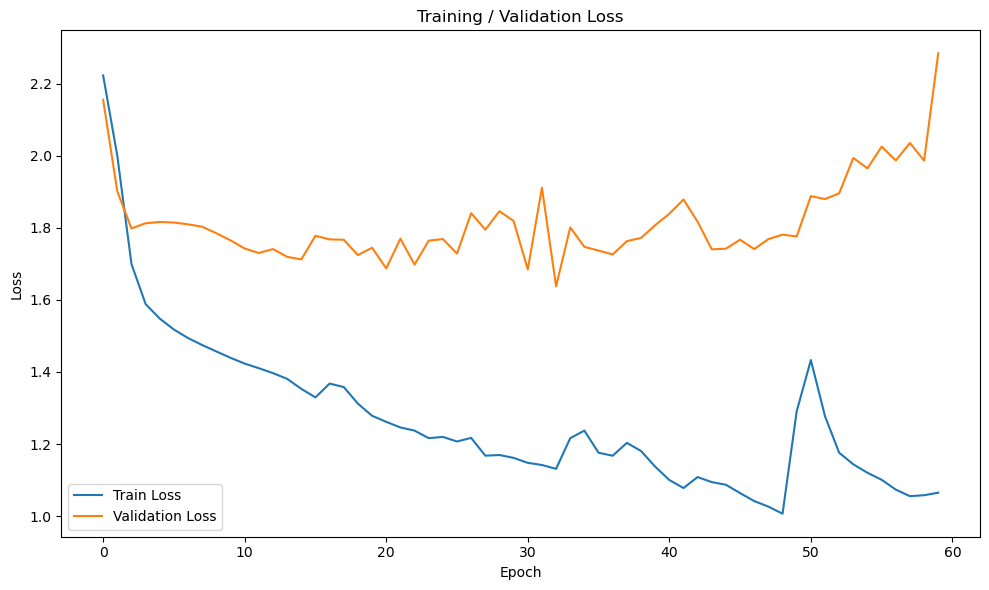

In [20]:
fig, ax = plt.subplots(figsize=(10, 6))
metrics_df = pd.read_csv(best_model_path_dir / "metrics.csv")
ax.plot(metrics_df["train_loss"], label="Train Loss")
ax.plot(metrics_df["val_loss"], label="Validation Loss")

ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Training / Validation Loss")
ax.legend()

fig.tight_layout()
fig.savefig(best_model_path_dir / "training_loss_plot.png", dpi=200, bbox_inches="tight")

plt.show()
plt.close(fig)



## plot loss curves (step train VS step val)

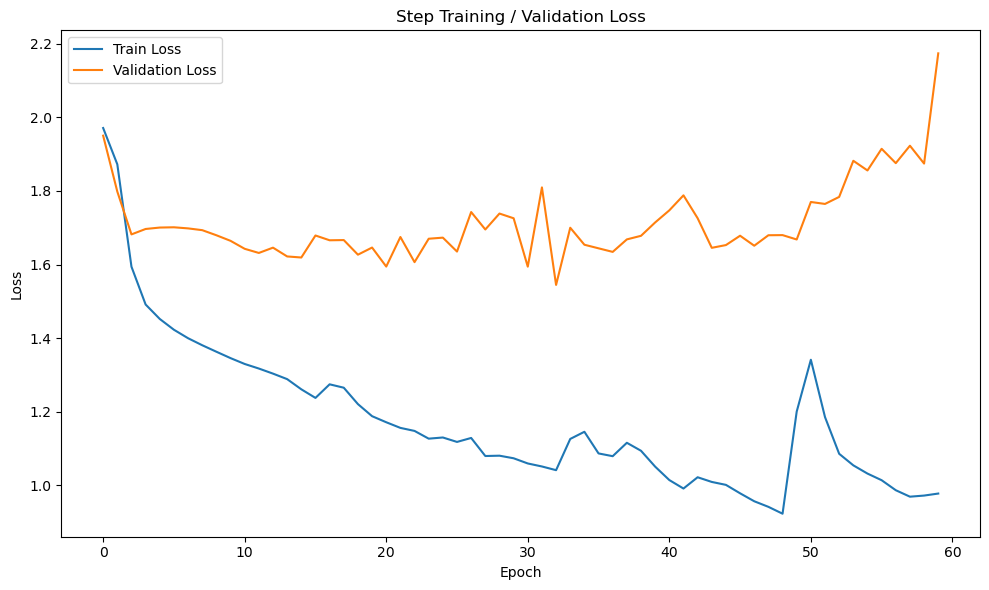

In [21]:
fig, ax = plt.subplots(figsize=(10, 6))
metrics_df = pd.read_csv(best_model_path_dir / "metrics.csv")
ax.plot(metrics_df["train_step_loss"], label="Train Loss")
ax.plot(metrics_df["val_step_loss"], label="Validation Loss")

ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Step Training / Validation Loss")
ax.legend()

fig.tight_layout()
fig.savefig(best_model_path_dir / "Step_training_loss_plot.png", dpi=200, bbox_inches="tight")

plt.show()
plt.close(fig)

## plot loss curves (progress train VS step val)

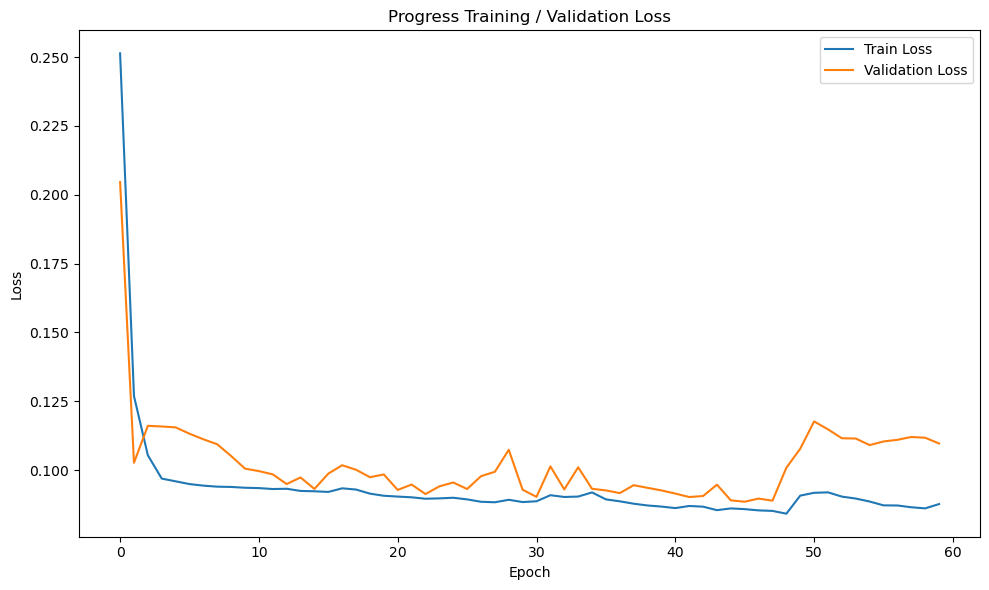

In [22]:
fig, ax = plt.subplots(figsize=(10, 6))
metrics_df = pd.read_csv(best_model_path_dir / "metrics.csv")
ax.plot(metrics_df["train_progress_loss"], label="Train Loss")
ax.plot(metrics_df["val_progress_loss"], label="Validation Loss")

ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Progress Training / Validation Loss")
ax.legend()

fig.tight_layout()
fig.savefig(best_model_path_dir / "Progress_training_loss_plot.png", dpi=200, bbox_inches="tight")

plt.show()
plt.close(fig)

In [23]:
import json
best_model_config = best_model_path_dir / "config.json"
best_model_config = json.loads(best_model_config.read_text())
input_dim = best_model_config["input_dim"]
hidden_dim = best_model_config["hidden_dim"]
num_steps = best_model_config["num_steps"]

In [24]:
model_eval = AssistLSTM(
    input_dim=input_dim,
    hidden_dim=hidden_dim,
    num_steps=num_steps
).to(device)

model_eval.load_state_dict(torch.load(best_model_path, map_location=device))

model_eval.eval()

AssistLSTM(
  (lstm): LSTM(18, 64, batch_first=True)
  (shared): Sequential(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (1): ReLU()
  )
  (step_head): Linear(in_features=64, out_features=7, bias=True)
  (progress_head): Linear(in_features=64, out_features=1, bias=True)
)

In [25]:
import pandas as pd
import json

total_loss = 0.0
total_step_loss = 0.0
total_progress_loss = 0.0
total_progress_mae = 0.0

total_correct = 0
total_samples = 0

all_rows = []

with torch.no_grad():
    for batch_idx, (x, y) in enumerate(test_loader):
        x = x.to(device)
        y_step = y["step"].to(device)
        y_progress = y["progress"].to(device)

        step_logits, progress_pred = model_eval(x)

        loss_step = ce_loss(step_logits, y_step)
        loss_progress = mse_loss(progress_pred, y_progress)
        loss = lambda_step * loss_step + lambda_progress * loss_progress

        preds_step = torch.argmax(step_logits, dim=1)
        progress_mae = torch.mean(torch.abs(progress_pred - y_progress))

        batch_size = x.size(0)

        total_loss += loss.item()
        total_step_loss += loss_step.item()
        total_progress_loss += loss_progress.item()
        total_progress_mae += progress_mae.item()

        total_correct += (preds_step == y_step).sum().item()
        total_samples += batch_size

        # save predictions
        for i in range(batch_size):
            all_rows.append({
                "batch_idx": batch_idx,
                "sample_idx_in_batch": i,
                "true_step": int(y_step[i].cpu().item()),
                "pred_step": int(preds_step[i].cpu().item()),
                "true_progress": float(y_progress[i].cpu().item()),
                "pred_progress": float(progress_pred[i].cpu().item()),
                "progress_abs_error": float(
                    torch.abs(progress_pred[i] - y_progress[i]).cpu().item()
                ),
            })

test_loss = total_loss / len(test_loader)
test_step_loss = total_step_loss / len(test_loader)
test_progress_loss = total_progress_loss / len(test_loader)
test_progress_mae = total_progress_mae / len(test_loader)
test_acc = total_correct / total_samples

results = {
    "test_loss": test_loss,
    "test_step_loss": test_step_loss,
    "test_progress_loss": test_progress_loss,
    "test_acc": test_acc,
    "test_progress_mae": test_progress_mae,
    "test_progress_mae_percent": test_progress_mae * 100,
}

pred_df = pd.DataFrame(all_rows)

In [26]:
pred_df.to_csv(best_model_path_dir / "test_predictions.csv", index=False)

with open(best_model_path_dir / "test_results.json", "w") as f:
    json.dump(results, f, indent=4)

print("Saved test predictions and results.")

Saved test predictions and results.


### Step prediction

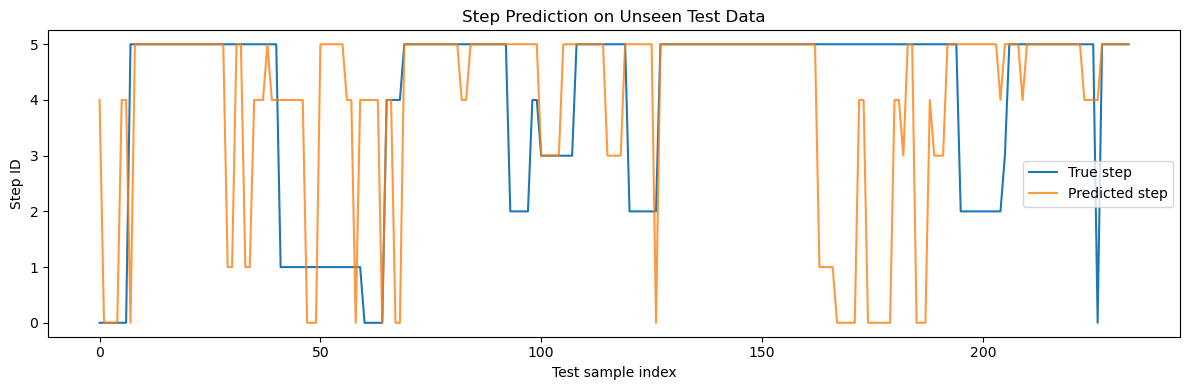

In [27]:
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(pred_df["true_step"].values, label="True step")
ax.plot(pred_df["pred_step"].values, label="Predicted step", alpha=0.8)

ax.set_xlabel("Test sample index")
ax.set_ylabel("Step ID")
ax.set_title("Step Prediction on Unseen Test Data")
ax.legend()

fig.tight_layout()
fig.savefig(best_model_path_dir / "step_prediction_plot.png", dpi=200, bbox_inches="tight")
plt.show()
plt.close(fig)

### Progress prediction & error

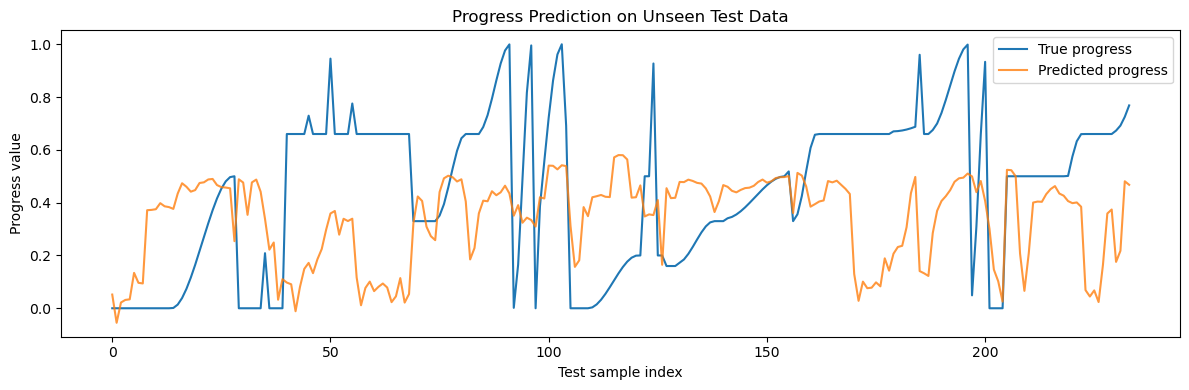

In [28]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(pred_df["true_progress"].values, label="True progress")
ax.plot(pred_df["pred_progress"].values, label="Predicted progress", alpha=0.8)

ax.set_xlabel("Test sample index")
ax.set_ylabel("Progress value")

ax.set_title("Progress Prediction on Unseen Test Data")
ax.legend()

fig.tight_layout()
fig.savefig(best_model_path_dir / "progress_prediction_plot.png", dpi=200, bbox_inches="tight")
plt.show()  
plt.close(fig)

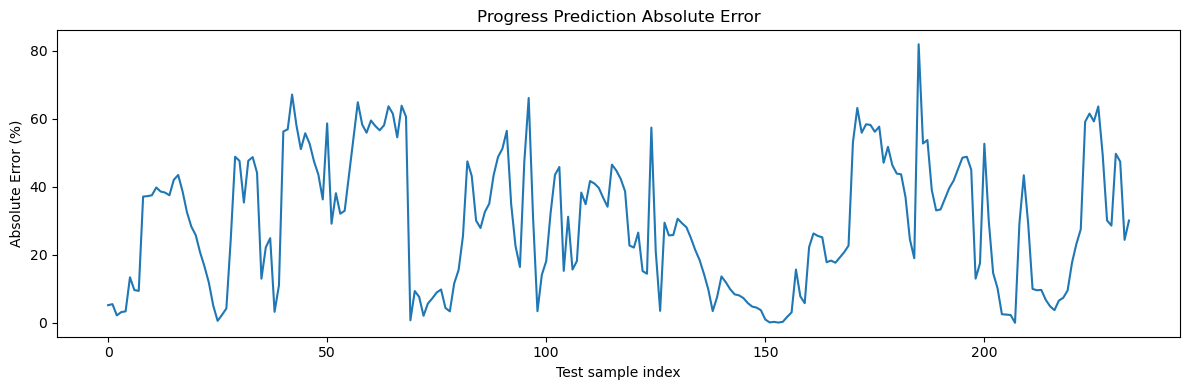

In [29]:
fig, ax  = plt.subplots(figsize=(12, 4))
ax.plot(pred_df["progress_abs_error"].values * 100, label="Absolute Error")
ax.set_xlabel("Test sample index")
ax.set_ylabel("Absolute Error (%)") 

ax.set_title("Progress Prediction Absolute Error")
fig.tight_layout()  
fig.savefig(best_model_path_dir / "progress_prediction_abs_error_plot.png", dpi=200, bbox_inches="tight")
plt.show()
plt.close(fig)

### step confusion

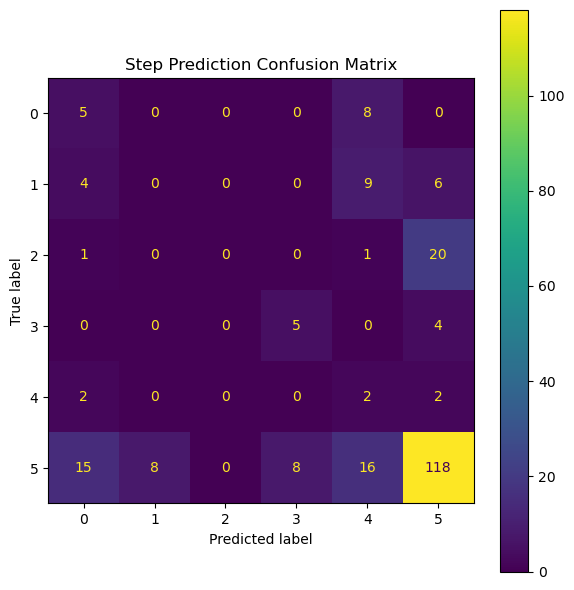

In [30]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(
    pred_df["true_step"],
    pred_df["pred_step"]
)

fig, ax = plt.subplots(figsize=(6, 6))

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=None, ax=ax)

ax.set_title("Step Prediction Confusion Matrix")
fig.tight_layout()

fig.savefig(
    best_model_path_dir / "step_prediction_confusion_matrix.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

### classification report

In [114]:
from sklearn.metrics import classification_report

print(
    classification_report(
        pred_df["true_step"],
        pred_df["pred_step"],
        digits=4
    )
)

              precision    recall  f1-score   support

           0     0.1875    0.0811    0.1132        37
           1     0.0000    0.0000    0.0000        26
           2     0.0000    0.0000    0.0000        11
           3     0.0000    0.0000    0.0000        13
           4     0.0714    0.0256    0.0377        39
           5     0.4457    0.9318    0.6029        88

    accuracy                         0.4019       214
   macro avg     0.1174    0.1731    0.1256       214
weighted avg     0.2287    0.4019    0.2744       214



c:\Users\loy49\anaconda3\envs\yolo_lstm\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\loy49\anaconda3\envs\yolo_lstm\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\loy49\anaconda3\envs\yolo_lstm\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", 